In [1]:
!pip install kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:00<00:00, 197MB/s]



In [4]:
# Extracting the compressed dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


**Importing the dependencies**

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [6]:
with_mask_files = os.listdir('/content/data/with_mask')
without_mask_files = os.listdir('/content/data/without_mask')

In [7]:
print('Number of mask images: ', len(with_mask_files))
print('Number of without mask images: ', len(without_mask_files))

Number of mask images:  3725
Number of without mask images:  3828


**Creating labels for images**

> with mask - 1

> without mask - 0





In [8]:
with_mask_labels = [1]*len(with_mask_files)
without_mask_labels = [0]*len(without_mask_files)

**Displayin the images**

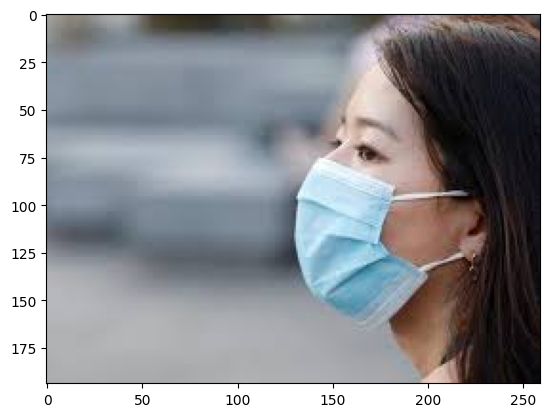

In [9]:
m_img = mpimg.imread('/content/data/with_mask/with_mask_2500.jpg')
imgplot = plt.imshow(m_img)
plt.show()

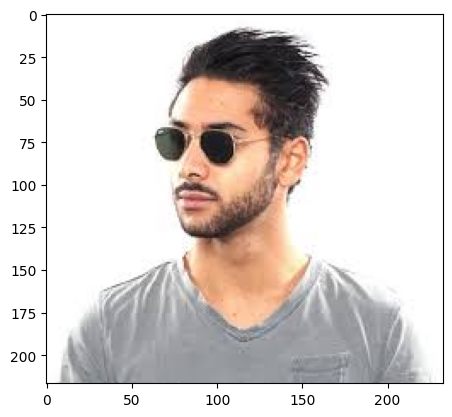

In [10]:
wm_img = mpimg.imread('/content/data/without_mask/without_mask_2500.jpg')
imgplot = plt.imshow(wm_img)
plt.show()

**Image Processing**

In [11]:
with_mask_path = '/content/data/with_mask/'

data = []

for file in with_mask_files:
  image = Image.open(with_mask_path + file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

without_mask_path = '/content/data/without_mask/'

for file in without_mask_files:
  image = Image.open(without_mask_path + file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [12]:
len(data)

7553

In [13]:
# Converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(with_mask_labels + without_mask_labels)
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


**Train Test Split**

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [15]:
# Data scaling

X_train_scaled = X_train/255.0
X_test_scaled = X_test/255.0

**Building the Convolutional Neural Network**

In [16]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense,MaxPooling2D,Flatten,Conv2D,Dropout,BatchNormalization
from keras.callbacks import EarlyStopping

In [33]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,305 (14.14 MB)

 Trainable params: 3,706,113 (14.14 MB)

 Non-trainable params: 192 (768.00 B)

In [35]:
# Compiling the neural network

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['acc'])

In [36]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [37]:
# Training the neural network

history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=15,callbacks=[early_stop])

Epoch 1/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - acc: 0.8488 - loss: 0.8006 - val_acc: 0.6793 - val_loss: 3.2301
Epoch 2/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.8950 - loss: 0.3237 - val_acc: 0.7058 - val_loss: 5.2154
Epoch 3/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.9253 - loss: 0.2092 - val_acc: 0.7884 - val_loss: 1.3253
Epoch 4/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9435 - loss: 0.1520 - val_acc: 0.8562 - val_loss: 0.5459
Epoch 5/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9481 - loss: 0.1331 - val_acc: 0.8959 - val_loss: 0.2547
Epoch 6/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9573 - loss: 0.1165 - val_acc: 0.7504 - val_loss: 1.0256
Epoch 7/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.9491 - loss: 0.1311 - val_acc: 0.8711 - val_loss: 0.3807
Epoch 8/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - acc: 0.9680 - loss: 0.0857 - val_acc: 0.9174 - val_loss: 0.2709


**Model Evaluation**

In [38]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.9067 - loss: 0.2343
Test Accuracy = 0.9066843390464783


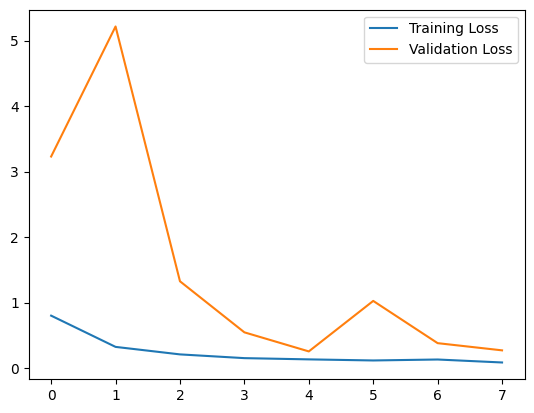

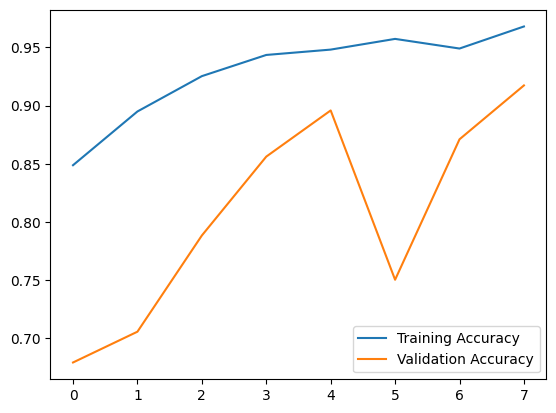

In [40]:
h = history

plt.plot(h.history['loss'], label = 'Training Loss')
plt.plot(h.history['val_loss'], label = 'Validation Loss')
plt.legend()
plt.show()

plt.plot(h.history['acc'], label = 'Training Accuracy')
plt.plot(h.history['val_acc'], label = 'Validation Accuracy')
plt.legend()
plt.show()

In [41]:
Y_pred_probs = model.predict(X_test_scaled)
Y_pred = (Y_pred_probs > 0.5).astype("int32")

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


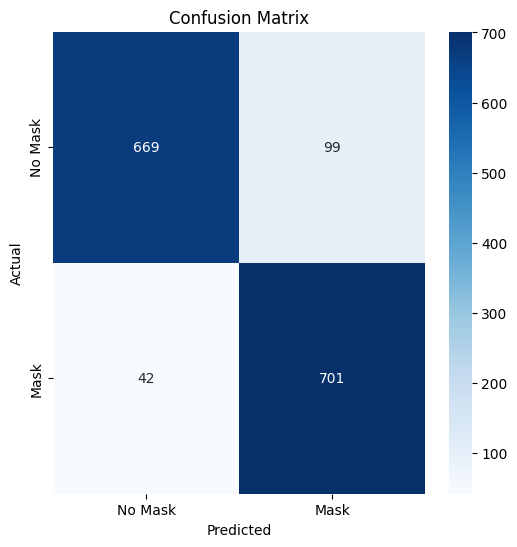

In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Mask', 'Mask'],
    yticklabels=['No Mask', 'Mask']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [43]:
print("\nClassification Report:\n")

print(classification_report(
    Y_test,
    Y_pred,
    target_names=['No Mask', 'Mask']
))


Classification Report:

              precision    recall  f1-score   support

     No Mask       0.94      0.87      0.90       768
        Mask       0.88      0.94      0.91       743

    accuracy                           0.91      1511
   macro avg       0.91      0.91      0.91      1511
weighted avg       0.91      0.91      0.91      1511



Path of image to be predicted/content/data/without_mask/without_mask_1000.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


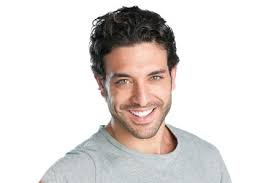

[[0.9547398]]
Prediction Label :  0
The person in the image is not wearing a mask


In [49]:
input_image_path = input('Path of image to be predicted')

input_image = cv2.imread(input_image_path)

# input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)

input_img_resized = cv2.resize(input_image, (128,128))
input_img_scaled = input_img_resized/255.0
input_img_reshaped = np.reshape(input_img_scaled, [1,128,128,3])
input_prediction = model.predict(input_img_reshaped)
cv2_imshow(input_image)
print(input_prediction)
input_pred_label = np.argmax(input_prediction)
print('Prediction Label : ',input_pred_label)

if input_pred_label == 1:
  print('The person in the image is wearing a mask')
else:
  print('The person in the image is not wearing a mask')